# Testing functions

## Load the GTFS data

In [1]:
import pandas as pd
import zipfile

def load_data(file_path):
    """From a ZIP file, unzip and load the CSV files (with .txt extension) into Pandas DataFrames, following a specific GTFS naming convention: agency, stops, routes, trips, shapes, etc."""
    tables = {}
    with zipfile.ZipFile(file_path, "r") as z:
        for filename in z.namelist():
            if filename.endswith(".txt") and not filename.startswith("__MACOS"):
                with z.open(filename) as f:
                    df_name = filename.split(".")[0]
                    tables[df_name] = pd.read_csv(f)
    return tables


# Load the data from the ZIP file in ./assets/GTFS_bUCR.zip
gtfs_data = load_data("./assets/GTFS_bUCR.zip")

## Show a glimpse of the data

In [2]:
gtfs_data["shapes"].head()  # Display the first few rows of the routes DataFrame

# Assign variables from gtfs_data
routes = gtfs_data["routes"]
trips = gtfs_data["trips"]
shapes = gtfs_data["shapes"]


## Convert to GeoDataFrames

Convert the `shapes` DataFrame to a GeoDataFrame with LineString geometries.

In [3]:
import geopandas as gpd
from shapely.geometry import LineString
from scenario_builder import load_config, validate_gtfs, Scenario
from IPython.display import display
import folium
from folium import plugins

# -------------------------
# Preparar shapes como GeoDataFrame
# -------------------------
shapes = gtfs_data["shapes"].sort_values(["shape_id", "shape_pt_sequence"])

def points_to_linestring(df):
    coords = list(zip(df["shape_pt_lon"].astype(float), df["shape_pt_lat"].astype(float)))
    if len(coords) == 1:
        return df
    return LineString(coords)

lines = shapes.groupby("shape_id").apply(points_to_linestring).reset_index(name="geometry")
gdf_shapes = gpd.GeoDataFrame(lines, geometry="geometry", crs="EPSG:4326")  # Set CRS explicitly
shapes = gdf_shapes

# -------------------------
# Crear escenario
# -------------------------
print("\nConstruyendo escenario...")

config = load_config("./config/scenario.yaml")
validate_gtfs(gtfs_data)
scenario = Scenario.from_gtfs(gtfs_data, config)

summary = scenario.summary()
print("\nEscenario creado con éxito:")
print(f"  • Rutas incluidas: {summary['num_routes']}")
print(f"  • Viajes incluidos: {summary['num_trips']}")
print(f"  • Contiene frecuencias: {summary['has_frequencies']}")

# -------------------------
# Visualización con estilo Google Maps - Mapa Completo
# -------------------------
trips = gtfs_data["trips"]

# Get the center coordinates from shapes
center_lat = shapes.geometry.iloc[0].centroid.y
center_lon = shapes.geometry.iloc[0].centroid.x

# Create map for all routes
print("\nMostrando mapa completo...")
tile_url = "http://mt0.google.com/vt/lyrs=r&hl=en&x={x}&y={y}&z={z}"
m_all = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    width='100%',    # make map responsive and full width
    height=900,      # increase height for better visibility
    tiles=tile_url,
    attr='Google Maps'
)

# Add the street view layer
folium.TileLayer(
    tiles='http://mt0.google.com/vt/lyrs=m&hl=en&x={x}&y={y}&z={z}',
    attr='Google Maps',
    name='Google Maps',
    overlay=True,
    control=True
).add_to(m_all)

# Add all routes with better styling
for _, row in shapes.iterrows():
    coords = [(y, x) for x, y in row.geometry.coords]
    # Add a shadow effect
    folium.PolyLine(
        coords,
        weight=7,
        color='#666666',
        opacity=0.5
    ).add_to(m_all)
    # Add the main route line
    folium.PolyLine(
        coords,
        weight=5,
        color='#0066ff',
        opacity=1.0
    ).add_to(m_all)

# Auto-fit bounds to show all routes
bounds = shapes.total_bounds
m_all.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# Add layer control
folium.LayerControl().add_to(m_all)

# Display the complete map
display(m_all)


Construyendo escenario...

Escenario creado con éxito:
  • Rutas incluidas: 2
  • Viajes incluidos: 130
  • Contiene frecuencias: False

Mostrando mapa completo...


C:\Users\ricar\AppData\Local\Temp\ipykernel_10808\2108823142.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lines = shapes.groupby("shape_id").apply(points_to_linestring).reset_index(name="geometry")


## Tick Engine

In [1]:
# Tick Engine for Simulation
import random
import time
from collections import deque
from typing import Callable, List, Dict, Any, Optional
import numpy as np
from dataclasses import dataclass
import statistics

class Event:
    def __init__(self, tick: int, callback: Callable, args: Optional[List]=None, kwargs: Optional[Dict]=None):
        self.tick = tick
        self.callback = callback
        self.args = args or []
        self.kwargs = kwargs or {}

    def execute(self):
        self.callback(*self.args, **self.kwargs)

@dataclass
class VelocityProfile:
    """Defines velocity characteristics for a vehicle"""
    base_speed: float
    acceleration: float
    deceleration: float
    max_speed: float
    min_speed: float
    
    def get_speed(self, current_speed: float, distance_to_stop: float, is_accelerating: bool) -> float:
        if is_accelerating:
            new_speed = current_speed + self.acceleration
            return min(new_speed, self.max_speed)
        elif distance_to_stop < 50:  # Start decelerating within 50 meters of stop
            new_speed = current_speed - self.deceleration
            return max(new_speed, self.min_speed)
        return current_speed

class DwellTimeGenerator:
    """Generates realistic dwell times based on historical patterns"""
    def __init__(self, mean_dwell: float = 30.0, std_dev: float = 10.0, min_dwell: float = 15.0, seed: int = None):
        self.mean_dwell = mean_dwell
        self.std_dev = std_dev
        self.min_dwell = min_dwell
        if seed is not None:
            random.seed(seed)
    
    def get_dwell_time(self) -> float:
        """Generate a realistic dwell time in seconds"""
        dwell = random.gauss(self.mean_dwell, self.std_dev)
        return max(self.min_dwell, dwell)

class Vehicle:
    def __init__(self, vehicle_id: str, route: str, shape: List[tuple], speed: float = 10.0):
        self.vehicle_id = vehicle_id
        self.route = route
        self.shape = shape  # List of (lon, lat) tuples
        self.position_idx = 0
        self.current_speed = 0.0
        self.finished = False
        self.is_dwelling = False
        self.dwell_time_remaining = 0
        
        # Initialize velocity profile
        self.velocity_profile = VelocityProfile(
            base_speed=speed,
            acceleration=0.00001,  # Adjusted for geographic coordinates
            deceleration=0.00002,
            max_speed=speed * 1.2,
            min_speed=speed * 0.5
        )
        
        # Initialize dwell time generator
        self.dwell_generator = DwellTimeGenerator(
            mean_dwell=30.0,
            std_dev=10.0,
            min_dwell=15.0
        )
        
        # Performance metrics
        self.total_distance = 0.0
        self.total_time = 0.0
        self.stops_made = 0
        self.average_speed = 0.0
        self.delay_s = 0
        self.extra_distance_m = 0
        self.hold_time_s = 0.0

    def move(self, tick_seconds):
        if self.finished:
            return
            
        # Handle dwell time
        if self.is_dwelling:
            self.dwell_time_remaining -= tick_seconds
            if self.dwell_time_remaining <= 0:
                self.is_dwelling = False
                self.current_speed = 0.0
            else:
                return
                
        # Calculate distance to next stop (simplified - could be enhanced with actual stop locations)
        next_stop_idx = min(self.position_idx + 10, len(self.shape) - 1)
        distance_to_stop = sum(
            np.linalg.norm(np.array(self.shape[i+1]) - np.array(self.shape[i]))
            for i in range(self.position_idx, next_stop_idx)
        )
        
        # Update speed based on velocity profile
        self.current_speed = self.velocity_profile.get_speed(
            self.current_speed,
            distance_to_stop,
            self.current_speed < self.velocity_profile.base_speed
        )
        
        # Move along the shape
        distance_to_travel = self.current_speed * tick_seconds
        self.total_distance += distance_to_travel
        self.total_time += tick_seconds
        
        while distance_to_travel > 0 and self.position_idx < len(self.shape) - 1:
            p1 = self.shape[self.position_idx]
            p2 = self.shape[self.position_idx + 1]
            segment_dist = np.linalg.norm(np.array(p2) - np.array(p1))
            
            if distance_to_travel >= segment_dist:
                self.position_idx += 1
                distance_to_travel -= segment_dist
                # Simulate stop at every 10th point (simplified stop simulation)
                if self.position_idx % 10 == 0 and not self.finished:
                    self.is_dwelling = True
                    self.dwell_time_remaining = self.dwell_generator.get_dwell_time()
                    self.stops_made += 1
                    break
            else:
                # Interpolate position (not updating position_idx for simplicity)
                break
                
        if self.position_idx >= len(self.shape) - 1:
            self.finished = True
            if self.total_time > 0:
                self.average_speed = self.total_distance / self.total_time

    def get_position(self):
        return self.shape[self.position_idx]
        
    def get_metrics(self):
        return {
            'total_distance': self.total_distance,
            'total_time': self.total_time,
            'stops_made': self.stops_made,
            'average_speed': self.average_speed,
            'current_speed': self.current_speed,
            'is_dwelling': self.is_dwelling,
            'dwell_time_remaining': self.dwell_time_remaining if self.is_dwelling else 0,
            'delay_s': self.delay_s,
            'extra_distance_m': self.extra_distance_m,
            'hold_time_s': self.hold_time_s
        }

class TickEngine:
    def __init__(self, vehicles, config=None, seed=42):
        self.vehicles = vehicles
        self.current_tick = 0
        self.event_queue = deque()
        self.state_history = []
        self.performance_metrics = {
            'tick_times': [],
            'total_vehicles': len(vehicles),
            'total_ticks': 0,
            'avg_tick_time': 0.0
        }
        random.seed(seed)
        np.random.seed(seed)

        # Inicializar perturbations engine
        self.perturb_engine = PerturbationEngine(config or {}, seed)

    def run(self, max_ticks=100, tick_interval_range=(1, 5)):
        for _ in range(max_ticks):
            tick_start_time = time.time()
            tick_seconds = random.randint(*tick_interval_range)
            self.current_tick += 1

            # Ejecutar eventos del tick
            events_this_tick = [e for e in list(self.event_queue) if e.tick == self.current_tick]
            for event in events_this_tick:
                event.execute()
                self.event_queue.remove(event)

            # Mover vehículos y aplicar perturbaciones
            for v in self.vehicles:
                v.move(tick_seconds)
                self.perturb_engine.apply_all(v)

            # Actualizar métricas
            tick_time = time.time() - tick_start_time
            self.performance_metrics['tick_times'].append(tick_time)
            self.performance_metrics['total_ticks'] = self.current_tick
            self.performance_metrics['avg_tick_time'] = statistics.mean(self.performance_metrics['tick_times'])

            state = self.get_state()
            state['performance'] = {
                'tick_time': tick_time,
                'avg_tick_time': self.performance_metrics['avg_tick_time']
            }
            self.state_history.append(state)

    def schedule_event(self, tick: int, callback: Callable, args: Optional[List]=None, kwargs: Optional[Dict]=None):
        event = Event(tick, callback, args, kwargs)
        self.event_queue.append(event)

    def get_state(self):
        return {
            'tick': self.current_tick,
            'vehicles': [
                {
                    'id': v.vehicle_id,
                    'position': v.get_position(),
                    'finished': v.finished,
                    'metrics': v.get_metrics()
                } for v in self.vehicles
            ]
        }
        
    def get_performance_summary(self):
        active_vehicles = sum(1 for v in self.vehicles if not v.finished)
        tick_times = self.performance_metrics['tick_times']
        
        return {
            'simulation_summary': {
                'total_ticks': self.performance_metrics['total_ticks'],
                'avg_tick_time': statistics.mean(tick_times) if tick_times else 0.0,
                'min_tick_time': min(tick_times) if tick_times else 0.0,
                'max_tick_time': max(tick_times) if tick_times else 0.0,
                'active_vehicles': active_vehicles,
                'completed_vehicles': len(self.vehicles) - active_vehicles
            },
            'vehicle_metrics': [v.get_metrics() for v in self.vehicles]
        }

## Simulating Vehicle Motion on Map

In [2]:
import folium
from IPython.display import display, clear_output
import time
from copy import deepcopy
import traceback
from perturbations import PerturbationEngine

def create_simulation_map(center_lat, center_lon):
    """Create a base map for simulation"""
    tile_url = "http://mt0.google.com/vt/lyrs=r&hl=en&x={x}&y={y}&z={z}"
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=14,
        width='100%',
        height=600,
        tiles=tile_url,
        attr='Google Maps'
    )
    return m


def visualize_vehicles_to_layer(m, vehicles_layer, vehicles):
    """Populate a FeatureGroup layer with the current vehicle markers.
    This completely removes and recreates the vehicles layer to ensure no old positions remain.
    """
    try:
        # Remove old vehicle markers from existing layer instead of creating a new one
        vehicles_layer._children = {}
        
        # Define vehicle colors
        vehicle_colors = {
            'V0': 'red',
            'V1': 'green',
            'V2': 'black'
        }

        for vehicle in vehicles:
            if not vehicle.finished:
                pos = vehicle.get_position()
                metrics = vehicle.get_metrics()
                popup_text = (
                    f"Vehicle {vehicle.vehicle_id}<br>"
                    f"Speed: {metrics['current_speed']:.6f}<br>"
                    f"{('DWELLING: ' + str(metrics['dwell_time_remaining']) + 's') if metrics['is_dwelling'] else 'Moving'}<br>"
                    f"Stops: {metrics['stops_made']}"
                )
                # Use yellow for dwelling, otherwise use the vehicle's assigned color
                color = 'yellow' if metrics['is_dwelling'] else vehicle_colors.get(vehicle.vehicle_id, 'red')
                
                # Create marker and add to the existing layer
                marker = folium.CircleMarker(
                    location=[pos[1], pos[0]],  # [lat, lon]
                    radius=5,
                    color=color,
                    fill=True,
                    popup=popup_text
                )
                marker.add_to(vehicles_layer)
        
        return vehicles_layer
        
    except Exception as e:
        print(f"Error in visualize_vehicles_to_layer: {str(e)}")
        print(traceback.format_exc())
        return vehicles_layer


try:
    # Create routes layer once (static)
    print("Creating routes layer...")
    routes_layer = folium.FeatureGroup(name='Routes')
    for _, row in shapes.iterrows():
        coords = [(y, x) for x, y in row.geometry.coords]
        folium.PolyLine(
            coords,
            weight=3,
            color='#0066ff',
            opacity=0.7
        ).add_to(routes_layer)

    # Initialize vehicles with actual route data
    print("Initializing vehicles...")
    random.seed(42)  # Set global seed
    vehicles = []
    # Get first 3 shapes using iloc
    for idx in range(min(3, len(shapes))):
        row = shapes.iloc[idx]
        coords = [(x, y) for x, y in row.geometry.coords]  # Note the coordinate order swap
        print(f"Creating vehicle {idx} with {len(coords)} coordinates")
        vehicles.append(Vehicle(
            vehicle_id=f"V{idx}",
            route=f"R{idx}",
            shape=coords,
            speed=0.0001  # Adjusted for geographic coordinates
        ))

    # Create tick engine
    print("Creating tick engine...")
    engine = TickEngine(vehicles, seed=123)

    # Create initial map once and add the static routes layer
    print("Creating initial map (single instance)...")
    center_lat = shapes.geometry.iloc[0].centroid.y
    center_lon = shapes.geometry.iloc[0].centroid.x
    m = create_simulation_map(center_lat, center_lon)
    routes_layer.add_to(m)

    # Create initial vehicles layer and add it to the map
    vehicles_layer = folium.FeatureGroup(name='Vehicles')
    vehicles_layer.add_to(m)

    # Add layer control
    folium.LayerControl().add_to(m)

    # Display the map once and keep a handle to update it in-place
    print("Displaying map (will be updated in-place)...")
    display_handle = display(m, display_id="simulation_map")

    # First tick initialization
    tick_start_time = time.time()
    engine.performance_metrics['tick_times'].append(time.time() - tick_start_time)

    # Run simulation with visualization
    print("Starting simulation...")
    simulation_start_time = time.time()
    for tick in range(50):  # Increased to 50 ticks for better observation
        try:
            # Update tick and move vehicles
            tick_seconds = random.randint(1, 5)
            engine.current_tick += 1
            for v in engine.vehicles:
                v.move(tick_seconds)

            # Update vehicles by updating the existing layer
            vehicles_layer = visualize_vehicles_to_layer(m, vehicles_layer, engine.vehicles)

            # Save state
            engine.state_history.append(engine.get_state())

            # Update the display
            display_handle.update(m)

            # Show performance metrics every 10 ticks
            if engine.current_tick % 10 == 0:
                perf = engine.get_performance_summary()
                print(f"\nTick {engine.current_tick} Performance Metrics:")
                print(f"Active vehicles: {len([v for v in vehicles if not v.finished])}")
                print(f"Average tick time: {perf['simulation_summary']['avg_tick_time']*1000:.2f}ms")
                print(f"Total stops made: {sum(v['stops_made'] for v in perf['vehicle_metrics'])}")

            time.sleep(0.5)  # Reduced delay for smoother visualization

        except Exception as e:
            print(f"Error during tick {tick}: {str(e)}")
            print(traceback.format_exc())
            break

    # Final performance summary
    try:
        simulation_time = time.time() - simulation_start_time
        final_perf = engine.get_performance_summary()
        print("\nFinal Simulation Statistics:")
        print(f"Total simulation time: {simulation_time:.2f}s")
        print(f"Average tick processing time: {final_perf['simulation_summary']['avg_tick_time']*1000:.2f}ms")
        print(f"Completed vehicles: {final_perf['simulation_summary']['completed_vehicles']}")
        print(f"Total stops made: {sum(v['stops_made'] for v in final_perf['vehicle_metrics'])}")
        print(f"Average vehicle speed: {statistics.mean(v['average_speed'] for v in final_perf['vehicle_metrics']):.6f}")
    except Exception as e:
        print(f"Error generating final statistics: {str(e)}")
        print(traceback.format_exc())

except Exception as e:
    print(f"Error during initialization: {str(e)}")
    print(traceback.format_exc())

print("\nSimulation completed!")

Creating routes layer...
Error during initialization: name 'shapes' is not defined
Traceback (most recent call last):
  File "/var/folders/xv/mf9c9gts3sbdlngj_yq7b3yw0000gn/T/ipykernel_33560/853551783.py", line 72, in <module>
    for _, row in shapes.iterrows():
                  ^^^^^^
NameError: name 'shapes' is not defined


Simulation completed!


## Main

✅ Unified metrics saved to /Users/fabian/Documents/dev/databus-sim/metrics.csv
✅ Metrics exported to metrics.csv

Final Simulation Statistics:
📊 Opening dashboard...
📊 Generando Dashboard con métricas reales (OTP, Headway, Gaps)...

⚠️ No hay datos de OTP registrados.
⚠️ No hay datos de headway registrados.


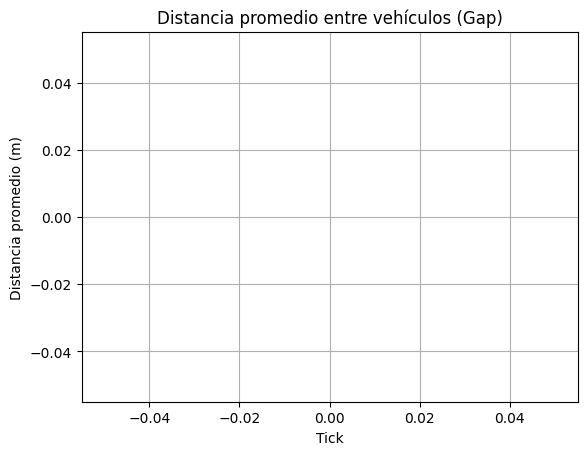

🚍 Distancia promedio entre vehículos: nan m


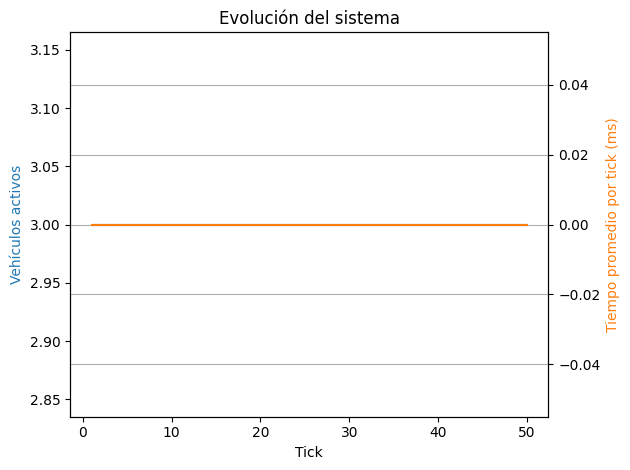


✅ Dashboard generado con éxito.
Total simulation time: 26.35s
Average tick processing time: 0.00ms
Completed vehicles: 0
Total stops made: 3
Average vehicle speed: 0.000000

Simulation completed!


In [6]:
%run main.py